# 05 — Explainability (SHAP)

This notebook:
- loads the best saved model pipeline (prefers tuned `xgb_best.joblib` / `lgb_best.joblib`)
- computes SHAP values on a sample of the test set
- produces a global summary plot and a per-sample explanation

Ethics reminder: interpret results as historical-pattern analysis only; do not use for profiling or enforcement.


Loaded: c:\Users\Wassim Rahali\Desktop\Crime IA\models\xgb_best.joblib


c:\Users\Wassim Rahali\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: [1 7 8]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\Wassim Rahali\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: [11]. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


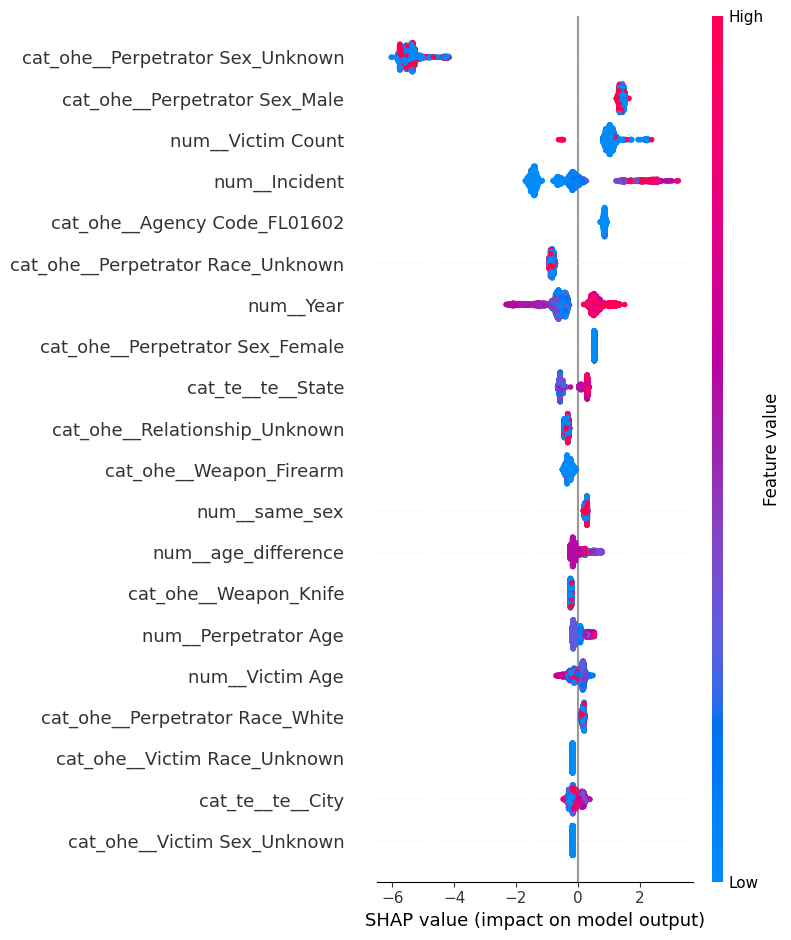

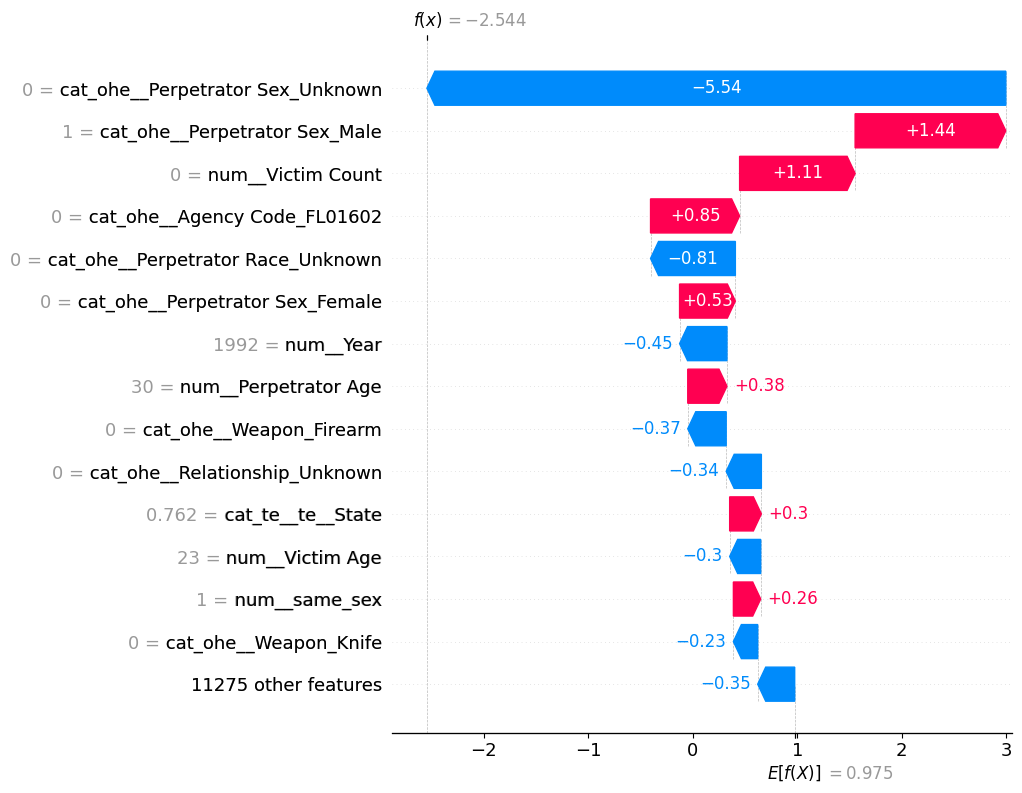

Saved figure: c:\Users\Wassim Rahali\Desktop\Crime IA\reports\figures\shap_summary.png


In [2]:
# SHAP analysis on best available model
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import shap

_cwd = Path.cwd()
PROJECT_ROOT = _cwd if (_cwd / "data").exists() else _cwd.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import DataPaths, load_processed_split
from src.train import dataframe_X_y, load_model

paths = DataPaths.from_project_root(PROJECT_ROOT)

# Pick model in priority order
candidates = [
    PROJECT_ROOT / "models" / "xgb_best.joblib",
    PROJECT_ROOT / "models" / "lgb_best.joblib",
    PROJECT_ROOT / "models" / "xgb_baseline.joblib",
    PROJECT_ROOT / "models" / "lgb_baseline.joblib",
    PROJECT_ROOT / "models" / "rf_baseline.joblib",
    PROJECT_ROOT / "models" / "logreg_baseline.joblib",
]
model_path = next((p for p in candidates if p.exists()), None)
if model_path is None:
    raise FileNotFoundError("No saved model found in models/. Run 03_baseline_models.ipynb or 04_tuning.ipynb first.")

pipe = load_model(model_path)
print("Loaded:", model_path)

# Load test split
test_df = load_processed_split(paths.processed_dir, "test")
X_test, y_test = dataframe_X_y(test_df)

# Sample for SHAP (keeps runtime reasonable)
SAMPLE_N = 2500
X_shap = X_test.sample(n=min(len(X_test), SAMPLE_N), random_state=42)

pre = pipe.named_steps["preprocess"]
model = pipe.named_steps["model"]

X_enc = pre.transform(X_shap)
try:
    feature_names = [str(n) for n in pre.get_feature_names_out()]
except Exception:
    feature_names = None

# SHAP expects dense for many plot types; convert a small sample
if hasattr(X_enc, "toarray"):
    X_enc_dense = X_enc.toarray()
else:
    X_enc_dense = np.asarray(X_enc)

model_name = model.__class__.__name__

# Choose explainer based on model type
if "LogisticRegression" in model_name:
    explainer = shap.LinearExplainer(model, X_enc_dense)
    shap_values = explainer.shap_values(X_enc_dense)
elif "XGB" in model_name or "LGBM" in model_name or "RandomForest" in model_name:
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_enc_dense)
else:
    raise TypeError(f"Unsupported model for SHAP in this notebook: {model_name}")

# Normalize SHAP output shape
# - Some explainers return list[class] for classification; pick positive class if possible.
if isinstance(shap_values, list):
    shap_values_for_plots = shap_values[1] if len(shap_values) > 1 else shap_values[0]
else:
    shap_values_for_plots = shap_values

# Global summary
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_for_plots, X_enc_dense, feature_names=feature_names, show=False)
plt.tight_layout()

fig_dir = PROJECT_ROOT / "reports" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_dir / "shap_summary.png", dpi=160, bbox_inches="tight")
plt.show()

# Per-sample explanation (waterfall)
row_idx = 0
base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = base_value[1] if len(base_value) > 1 else base_value[0]

exp = shap.Explanation(
    values=shap_values_for_plots[row_idx],
    base_values=base_value,
    data=X_enc_dense[row_idx],
    feature_names=feature_names,
)
shap.plots.waterfall(exp, max_display=15)

print("Saved figure:", fig_dir / "shap_summary.png")